In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vedavyasv/usa-housing/USA_Housing.csv


In [14]:
df = pd.read_csv('/kaggle/input/datasets/vedavyasv/usa-housing/USA_Housing.csv')
print(df.head())
print(df.shape)
print(df.columns.tolist())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [15]:
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                        2.000000       172.61

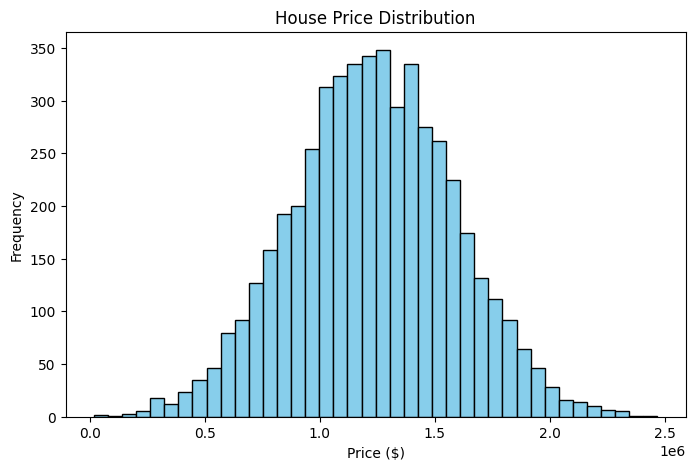

In [16]:
plt.figure(figsize=(8,5))
df['Price'].plot(kind='hist', bins=40, color='skyblue', edgecolor='black')
plt.title('House Price Distribution')
plt.xlabel('Price ($)')
plt.show()

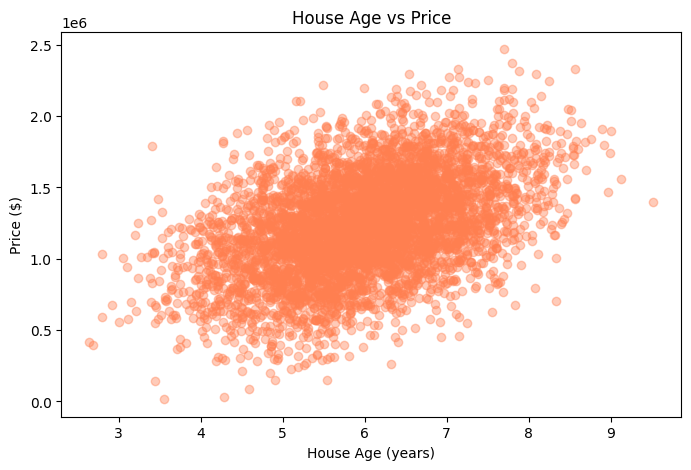

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['Avg. Area House Age'], df['Price'], color='coral', alpha=0.4)
plt.title('House Age vs Price')
plt.xlabel('House Age (years)')
plt.ylabel('Price ($)')
plt.show()

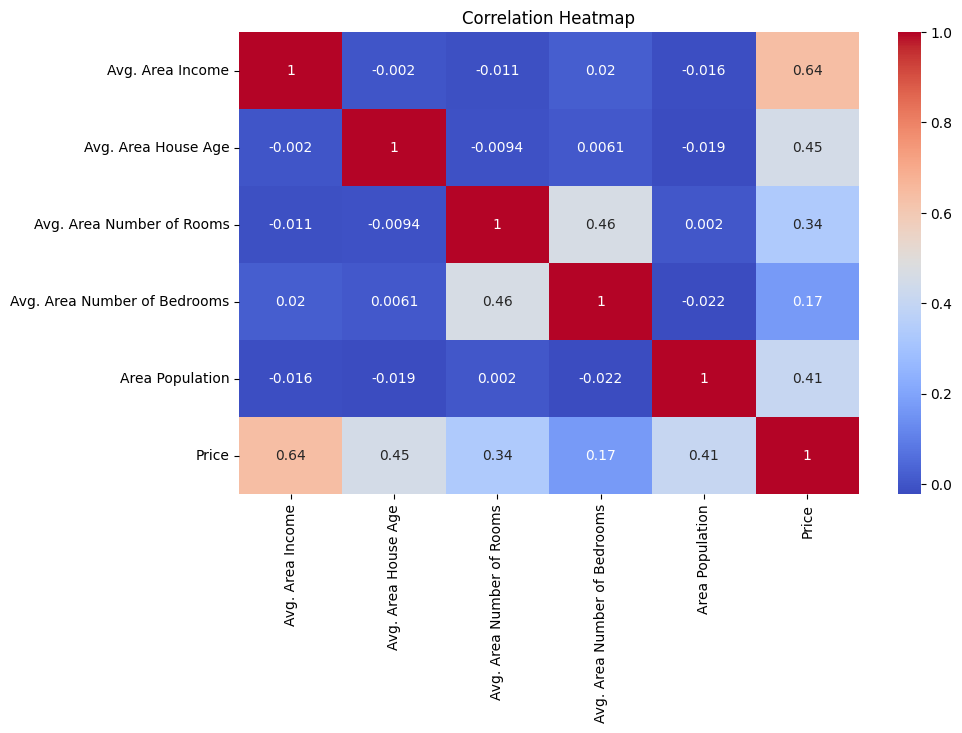

In [18]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
# Drop text column
X = df.drop(['Price', 'Address'], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features: {X.columns.tolist()}")

Training samples: 4000
Testing samples: 1000
Features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']


In [20]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


In [21]:
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"Model Accuracy: {round(r2*100, 2)}%")

MSE: 14340640851.43
R2 Score: 0.88
Model Accuracy: 88.34%


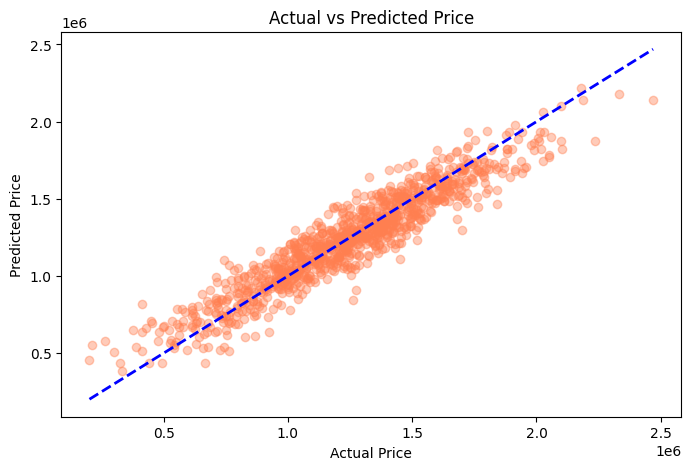

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions, color='coral', alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'b--', linewidth=2)
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

/tmp/ipykernel_137/1657577039.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values,


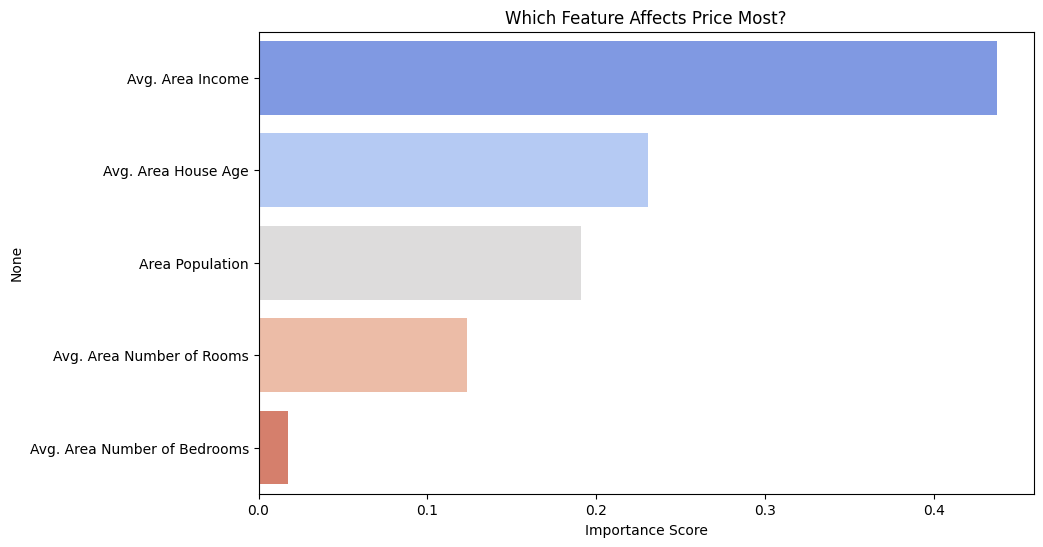

In [23]:
feat_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values,
            y=feat_importance.index,
            palette='coolwarm')
plt.title('Which Feature Affects Price Most?')
plt.xlabel('Importance Score')
plt.show()

In [24]:
print("=== HOUSE PRICE PREDICTION SUMMARY ===")
print(f"Total Houses: {len(df)}")
print(f"Average Price: ${df['Price'].mean():,.2f}")
print(f"Highest Price: ${df['Price'].max():,.2f}")
print(f"Lowest Price: ${df['Price'].min():,.2f}")
print(f"Model Used: Random Forest Regressor")
print(f"Model Accuracy: {round(r2*100, 2)}%")

=== HOUSE PRICE PREDICTION SUMMARY ===
Total Houses: 5000
Average Price: $1,232,072.65
Highest Price: $2,469,065.59
Lowest Price: $15,938.66
Model Used: Random Forest Regressor
Model Accuracy: 88.34%
